#CONNECT DRIVE

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#TRANSFORMER

import & setup

In [6]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
torch.manual_seed(42)

model

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

class WindTransformer(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, seq_len=12):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos = PositionalEncoding(d_model, seq_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True, dropout=0.1
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, 3)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        x = self.encoder(x)
        x = self.norm(x)
        return self.fc(x[:, -1, :])

def train_transformer(file_path, station_name):
    print(f"\nXử lý trạm: {station_name}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Đang chạy trên thiết bị:", device)

    if not os.path.exists(file_path):
        print(f"Lỗi: Không tìm thấy file {file_path}")
        return

    df = pd.read_csv(file_path) # đọc và setup data
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    df = df.dropna()

    n = len(df)
    train_end = int(n * 0.7)

    X_df = df.copy()
    Y_df = df[['wind_speed']]

    scaler_X = MinMaxScaler()
    scaler_Y = MinMaxScaler()

    scaler_X.fit(X_df.iloc[:train_end])
    scaler_Y.fit(Y_df.iloc[:train_end])

    X_scaled = scaler_X.transform(X_df)
    Y_scaled = scaler_Y.transform(Y_df)

    seq_len = 12
    X_list, Y_list = [], []

    for i in range(len(X_scaled) - seq_len - 10):
        X_list.append(X_scaled[i:i+seq_len])
        # Hiện tại là (i + seq_len - 1)
        y_30  = Y_scaled[i + seq_len + 1][0] # +2
        y_60  = Y_scaled[i + seq_len + 3][0] # +4
        y_120 = Y_scaled[i + seq_len + 7][0] # +6
        Y_list.append([y_30, y_60, y_120])

    X_np = np.array(X_list, dtype=np.float32)
    Y_np = np.array(Y_list, dtype=np.float32)

    n_w = len(X_np)
    w_train = int(n_w * 0.7)
    w_val = int(n_w * 0.85)

    X_train = torch.tensor(X_np[:w_train]).to(device)
    Y_train = torch.tensor(Y_np[:w_train]).to(device)
    X_val = torch.tensor(X_np[w_train:w_val]).to(device)
    Y_val = torch.tensor(Y_np[w_train:w_val]).to(device)
    X_test = torch.tensor(X_np[w_val:]).to(device)
    Y_test = torch.tensor(Y_np[w_val:]).to(device)

    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=64, shuffle=False)

    model = WindTransformer(input_size=X_train.shape[2], seq_len=seq_len).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    best_loss = float('inf')
    patience = 10
    counter = 0

    epoch_times = []
    train_losses = []
    val_losses = []
    total_train_start = time.time()

    print("\nBắt đầu quá trình huấn luyện...")
    for epoch in range(50):
        epoch_start = time.time()
        model.train()
        epoch_loss = 0

        for Xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        train_loss = epoch_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for Xb_v, yb_v in val_loader:
                val_pred = model(Xb_v)
                val_loss += criterion(val_pred, yb_v).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f"/content/{station_name}_best_transformer.pt")
            best_epoch_msg = f" (New Best)"
        else:
            counter += 1
            best_epoch_msg = ""

        if (epoch + 1) % 5 == 0 or best_epoch_msg != "":
            print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f} | Time: {epoch_time:.2f}s{best_epoch_msg}")

        if counter >= patience:
            print(f"Early stopping kích hoạt tại Epoch {epoch+1}!")
            break

    total_train_time = time.time() - total_train_start
    avg_epoch_time = np.mean(epoch_times)
    print("\nSố liệu chi phí tài nguyên")
    print(f"Tổng thời gian huấn luyện : {total_train_time:.2f} s")
    print(f"Thời gian trung bình/epoch: {avg_epoch_time:.2f} s")

    model.load_state_dict(torch.load(f"/content/{station_name}_best_transformer.pt"))
    model.cpu()
    model.eval()
    sample_input_cpu = X_test[0:1].cpu()

    with torch.no_grad():
        for _ in range(10): _ = model(sample_input_cpu)

    latencies = []
    with torch.no_grad():
        for _ in range(100):
            start_infer = time.time()
            _ = model(sample_input_cpu)
            latencies.append((time.time() - start_infer) * 1000)

    avg_latency = np.mean(latencies)
    print(f"Độ trễ suy luận (CPU Latency): {avg_latency:.4f} ms/mẫu")

    model.to(device)
    model.eval()
    with torch.no_grad():
        y_pred_list = []
        test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=256, shuffle=False)
        for Xb_t, _ in test_loader:
            y_pred_list.append(model(Xb_t).cpu().numpy())

        y_pred_scaled = np.vstack(y_pred_list)
        y_true_scaled = Y_test.cpu().numpy()

        y_pred = scaler_Y.inverse_transform(y_pred_scaled)
        y_true = scaler_Y.inverse_transform(y_true_scaled)

    print("\nResult test")
    horizons = ["30min", "60min", "120min"]
    for i, h in enumerate(horizons):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        print(f"Horizon {h:6s}: RMSE = {rmse:.4f} | MAE = {mae:.4f} | R2 = {r2:.4f}")

    overall_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\nGlobal RMSE: {overall_rmse:.4f}")

    # Biểu đồ
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss', color='blue', linewidth=1.5)
    plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=1.5)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title(f"Loss Curve (Transformer) - {station_name}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    plot_steps = 200
    horizons_labels = ["30 Phút", "60 Phút", "120 Phút"]

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"Transformer Forecast vs Actual - {station_name}", fontsize=14, fontweight='bold')

    for i in range(3):
        axes[i].plot(y_true[:plot_steps, i], label="Thực tế (Actual)", color='black', linewidth=1.5)
        axes[i].plot(y_pred[:plot_steps, i], label="Dự báo (Predicted)", color='red', linestyle='--', linewidth=1.5)
        axes[i].set_ylabel("Wind Speed (m/s)")
        axes[i].set_title(f"Horizon: {horizons_labels[i]}")
        axes[i].legend(loc="upper right")
        axes[i].grid(True, linestyle='--', alpha=0.5)

    axes[2].set_xlabel("Time Steps (15-min intervals)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Transformer Regression Fit - {station_name}", fontsize=14, fontweight='bold')

    for i in range(3):
        axes[i].scatter(y_true[:, i], y_pred[:, i], alpha=0.3, color='seagreen', s=10)
        min_val = min(y_true[:, i].min(), y_pred[:, i].min())
        max_val = max(y_true[:, i].max(), y_pred[:, i].max())
        axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

        axes[i].set_title(f"{horizons_labels[i]} (R2: {r2_score(y_true[:, i], y_pred[:, i]):.3f})")
        axes[i].set_xlabel("Actual Wind Speed (m/s)")
        if i == 0: axes[i].set_ylabel("Predicted Wind Speed (m/s)")
        axes[i].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

Run

TRANSFORMER...

Đang xử lý: Tram_A_DatLien

Xử lý trạm: Tram_A_DatLien
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00330 | Val Loss: 0.00072 | Time: 8.97s (New Best)
Epoch 04 | Train Loss: 0.00069 | Val Loss: 0.00057 | Time: 8.41s (New Best)
Epoch 05 | Train Loss: 0.00062 | Val Loss: 0.00070 | Time: 8.13s
Epoch 06 | Train Loss: 0.00059 | Val Loss: 0.00055 | Time: 8.75s (New Best)
Epoch 09 | Train Loss: 0.00052 | Val Loss: 0.00054 | Time: 8.82s (New Best)
Epoch 10 | Train Loss: 0.00051 | Val Loss: 0.00054 | Time: 7.74s
Epoch 13 | Train Loss: 0.00047 | Val Loss: 0.00053 | Time: 8.46s (New Best)
Epoch 14 | Train Loss: 0.00047 | Val Loss: 0.00051 | Time: 8.98s (New Best)
Epoch 15 | Train Loss: 0.00046 | Val Loss: 0.00056 | Time: 8.07s
Epoch 17 | Train Loss: 0.00044 | Val Loss: 0.00050 | Time: 9.02s (New Best)
Epoch 20 | Train Loss: 0.00041 | Val Loss: 0.00054 | Time: 8.40s
Epoch 25 | Train Loss: 0.00035 | Val Loss: 0.00054 | Time: 8.71s
Early sto

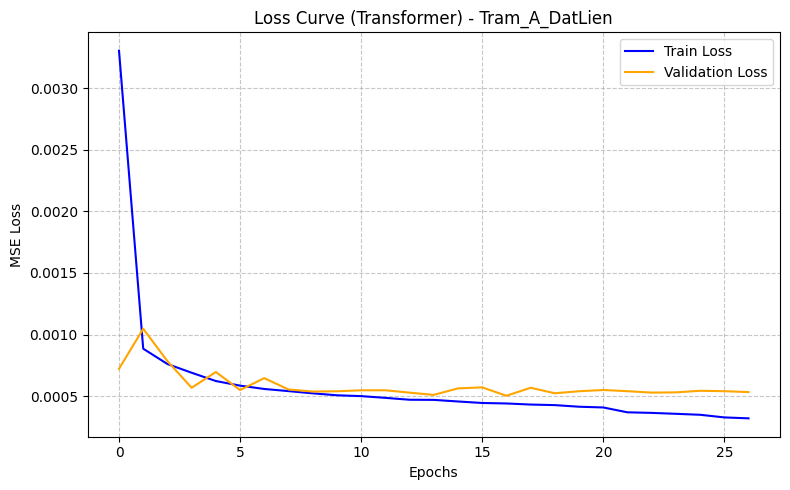

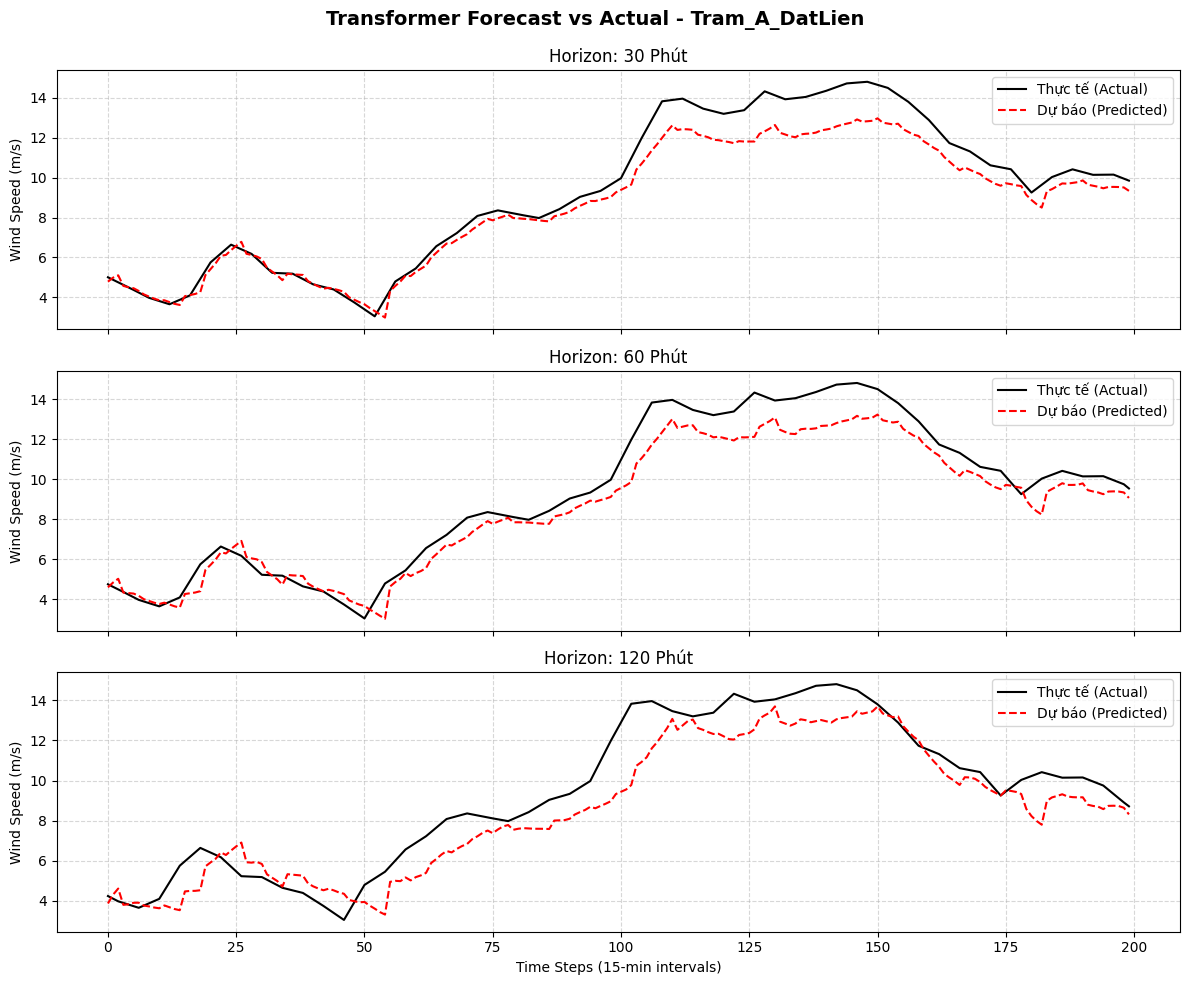

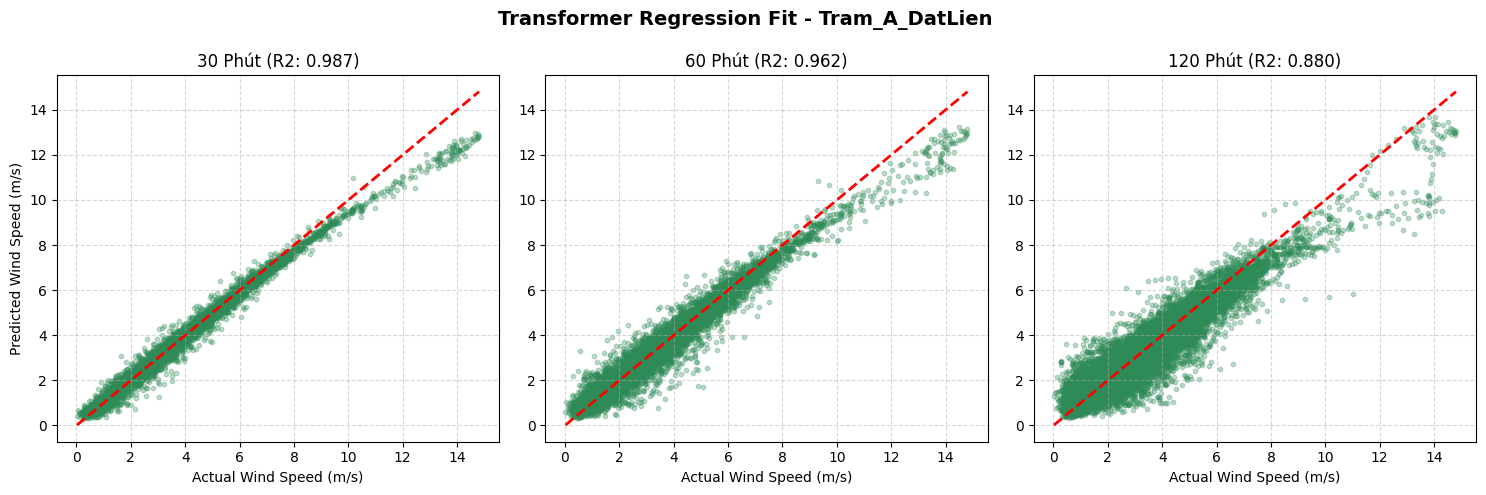


Đang xử lý: Tram_B_VenBien

Xử lý trạm: Tram_B_VenBien
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00537 | Val Loss: 0.00081 | Time: 9.05s (New Best)
Epoch 03 | Train Loss: 0.00078 | Val Loss: 0.00056 | Time: 9.18s (New Best)
Epoch 05 | Train Loss: 0.00065 | Val Loss: 0.00051 | Time: 8.05s (New Best)
Epoch 08 | Train Loss: 0.00056 | Val Loss: 0.00050 | Time: 8.64s (New Best)
Epoch 10 | Train Loss: 0.00054 | Val Loss: 0.00047 | Time: 8.20s (New Best)
Epoch 15 | Train Loss: 0.00045 | Val Loss: 0.00046 | Time: 8.64s (New Best)
Epoch 16 | Train Loss: 0.00045 | Val Loss: 0.00045 | Time: 8.35s (New Best)
Epoch 17 | Train Loss: 0.00044 | Val Loss: 0.00044 | Time: 9.00s (New Best)
Epoch 20 | Train Loss: 0.00042 | Val Loss: 0.00048 | Time: 8.90s
Epoch 25 | Train Loss: 0.00038 | Val Loss: 0.00044 | Time: 8.81s
Early stopping kích hoạt tại Epoch 27!

Số liệu chi phí tài nguyên
Tổng thời gian huấn luyện : 233.30 s
Thời gian trung bình/epoch: 8.64 s
Độ t

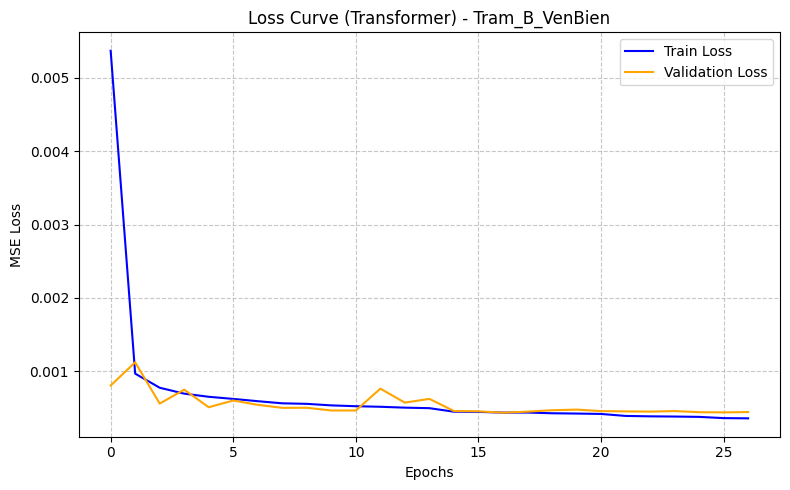

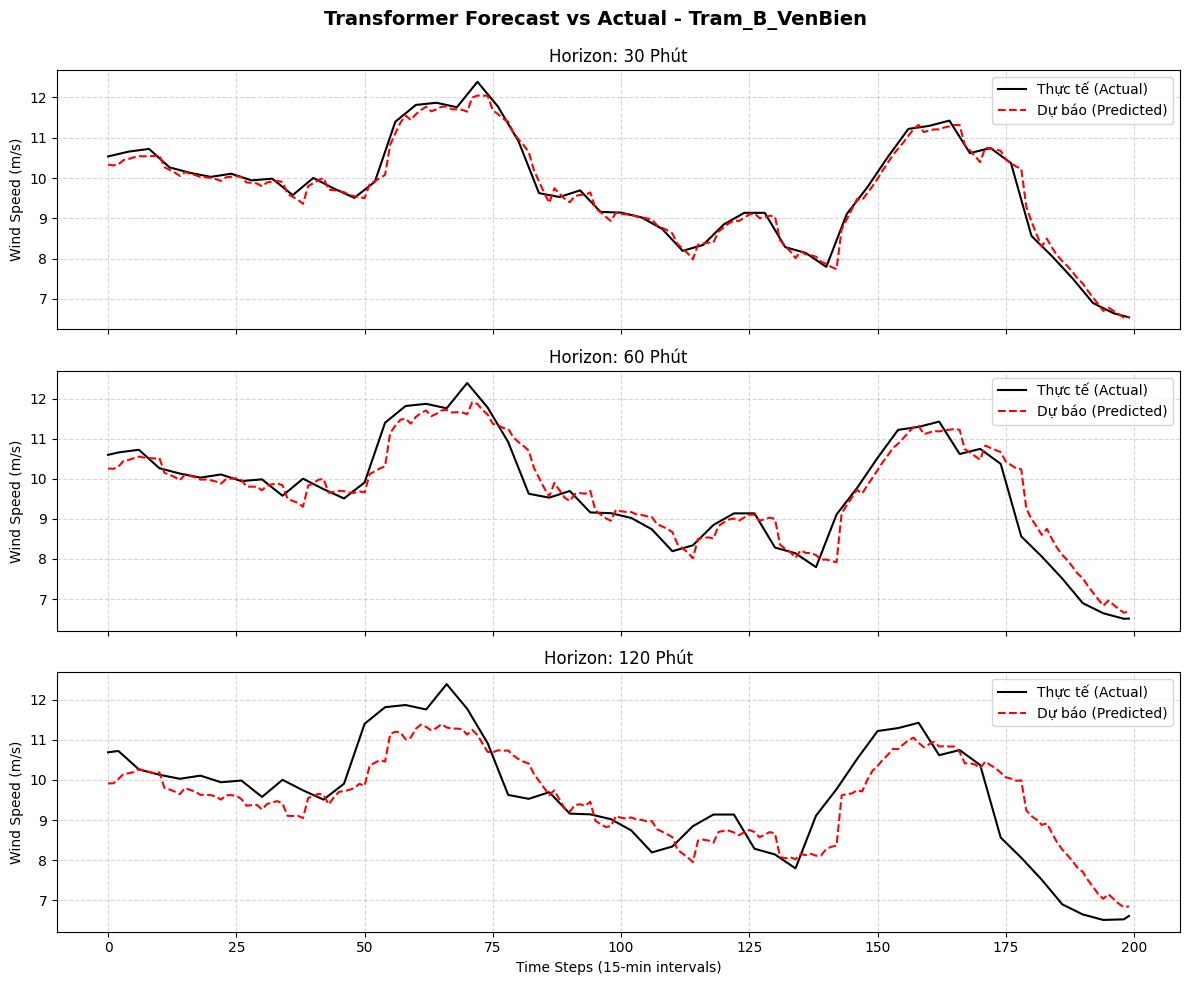

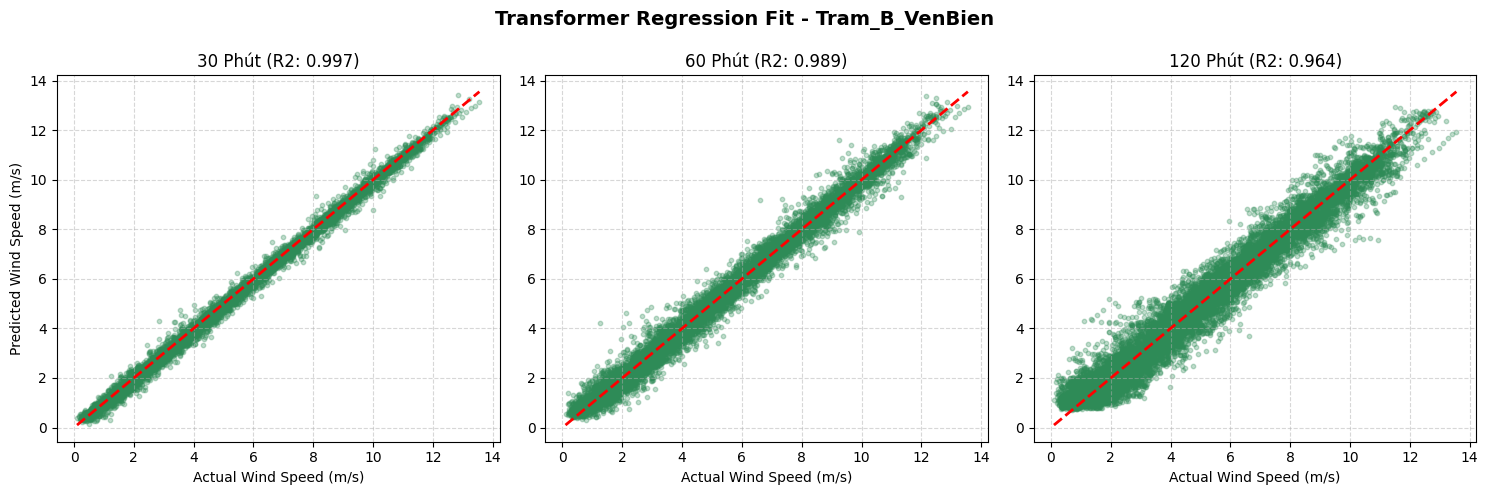


Đang xử lý: Tram_C_DoiNui

Xử lý trạm: Tram_C_DoiNui
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00541 | Val Loss: 0.00122 | Time: 8.99s (New Best)
Epoch 02 | Train Loss: 0.00139 | Val Loss: 0.00113 | Time: 8.13s (New Best)
Epoch 03 | Train Loss: 0.00122 | Val Loss: 0.00104 | Time: 8.56s (New Best)
Epoch 04 | Train Loss: 0.00112 | Val Loss: 0.00102 | Time: 8.87s (New Best)
Epoch 05 | Train Loss: 0.00107 | Val Loss: 0.00090 | Time: 7.89s (New Best)
Epoch 10 | Train Loss: 0.00084 | Val Loss: 0.00090 | Time: 8.16s (New Best)
Epoch 11 | Train Loss: 0.00083 | Val Loss: 0.00088 | Time: 8.93s (New Best)
Epoch 14 | Train Loss: 0.00078 | Val Loss: 0.00088 | Time: 9.04s (New Best)
Epoch 15 | Train Loss: 0.00077 | Val Loss: 0.00091 | Time: 8.62s
Epoch 17 | Train Loss: 0.00074 | Val Loss: 0.00087 | Time: 8.99s (New Best)
Epoch 18 | Train Loss: 0.00073 | Val Loss: 0.00087 | Time: 8.10s (New Best)
Epoch 20 | Train Loss: 0.00070 | Val Loss: 0.00092 | Time:

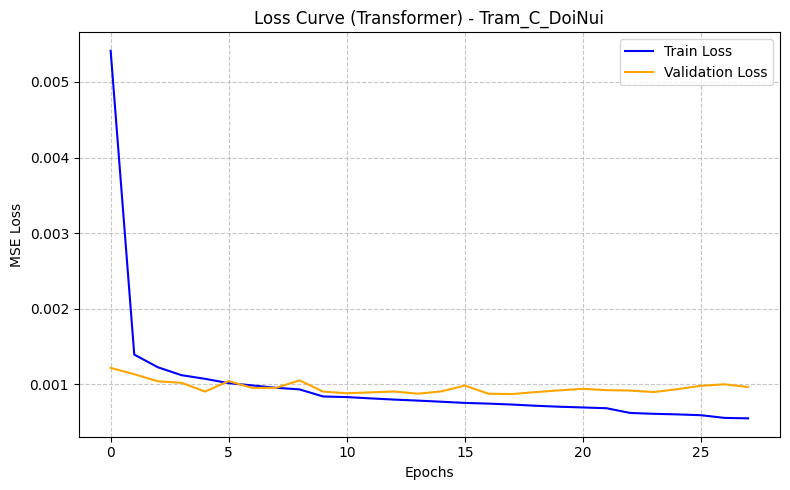

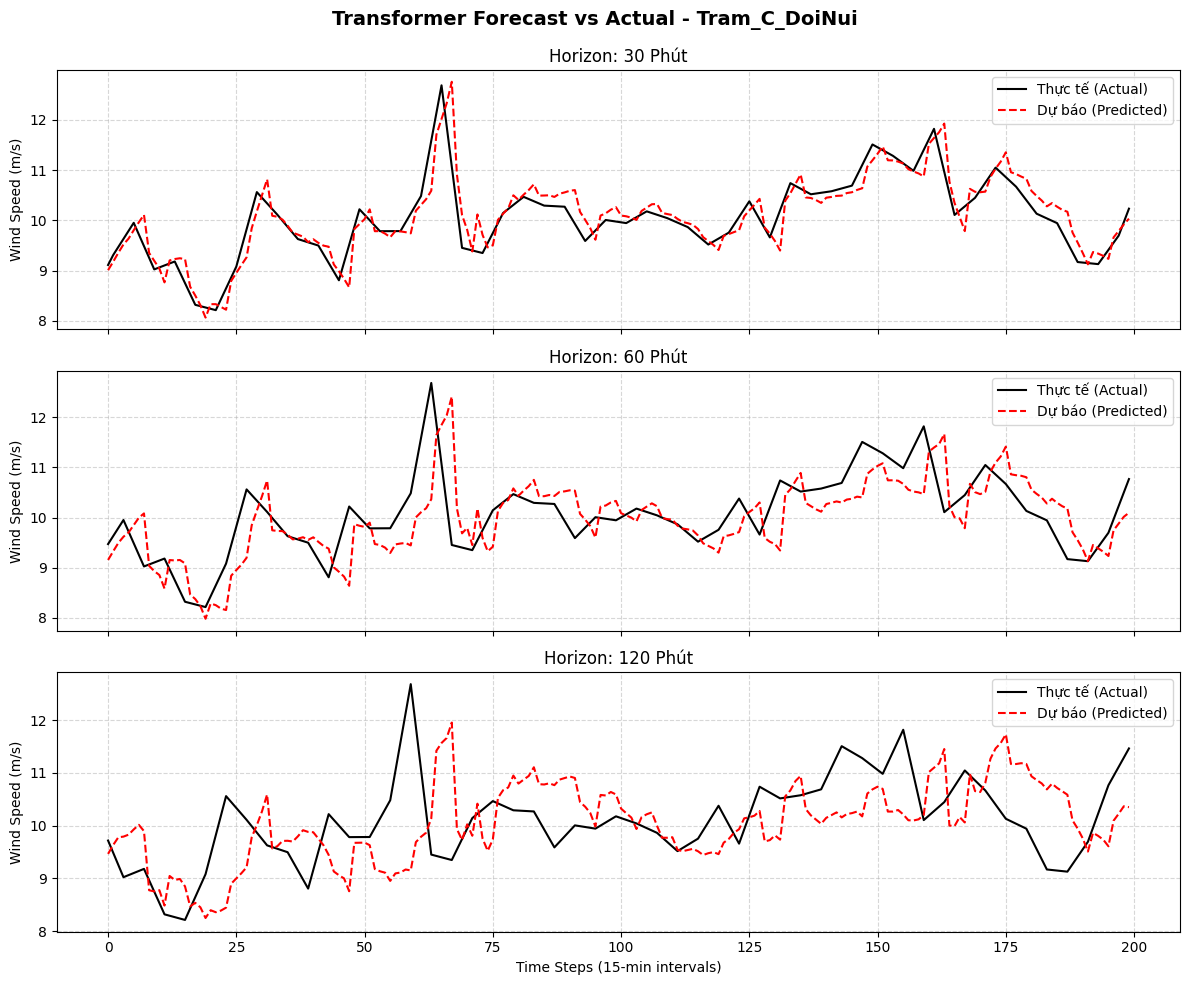

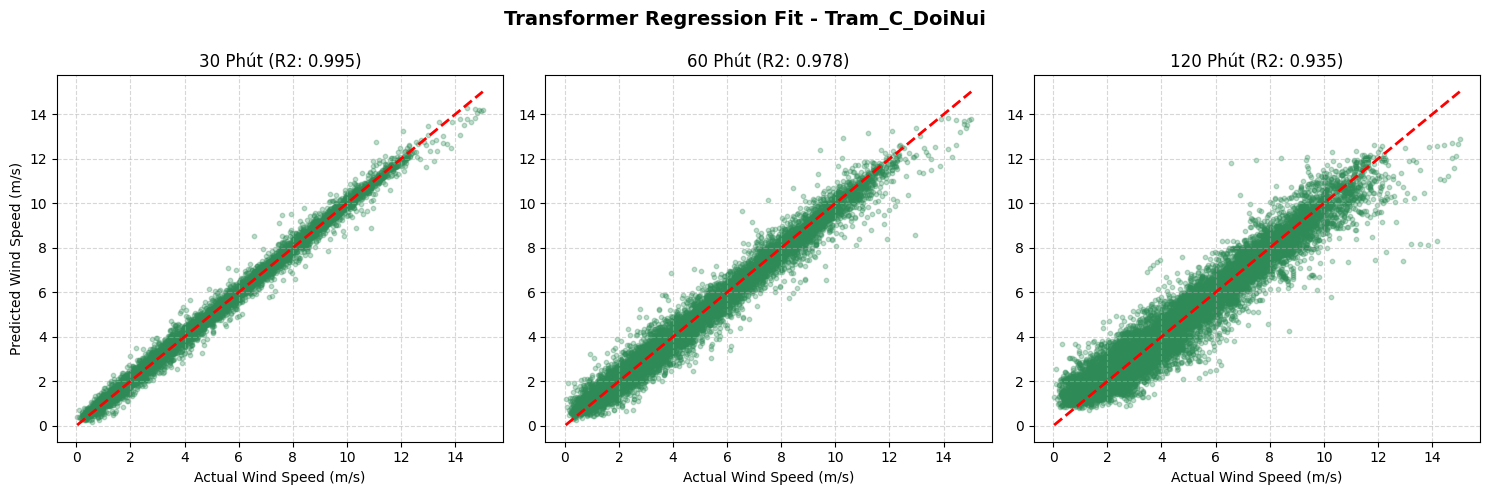


Đang xử lý: Tram_D_NgoaiKhoi

Xử lý trạm: Tram_D_NgoaiKhoi
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00369 | Val Loss: 0.00073 | Time: 8.54s (New Best)
Epoch 02 | Train Loss: 0.00058 | Val Loss: 0.00032 | Time: 8.50s (New Best)
Epoch 04 | Train Loss: 0.00040 | Val Loss: 0.00029 | Time: 7.93s (New Best)
Epoch 05 | Train Loss: 0.00036 | Val Loss: 0.00043 | Time: 8.98s
Epoch 10 | Train Loss: 0.00026 | Val Loss: 0.00027 | Time: 8.39s (New Best)
Epoch 11 | Train Loss: 0.00026 | Val Loss: 0.00026 | Time: 8.79s (New Best)
Epoch 15 | Train Loss: 0.00024 | Val Loss: 0.00027 | Time: 8.22s
Epoch 16 | Train Loss: 0.00022 | Val Loss: 0.00026 | Time: 9.04s (New Best)
Epoch 20 | Train Loss: 0.00021 | Val Loss: 0.00026 | Time: 7.88s
Epoch 23 | Train Loss: 0.00019 | Val Loss: 0.00025 | Time: 8.05s (New Best)
Epoch 25 | Train Loss: 0.00019 | Val Loss: 0.00026 | Time: 8.24s
Epoch 30 | Train Loss: 0.00017 | Val Loss: 0.00026 | Time: 8.49s
Early stopping kích 

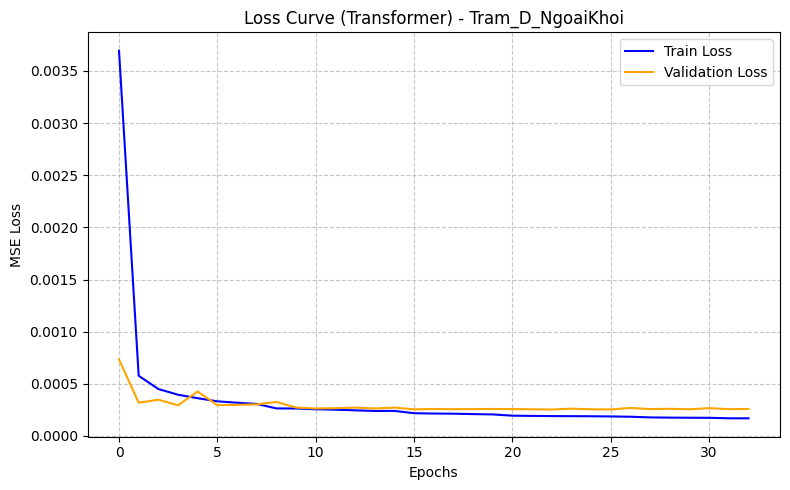

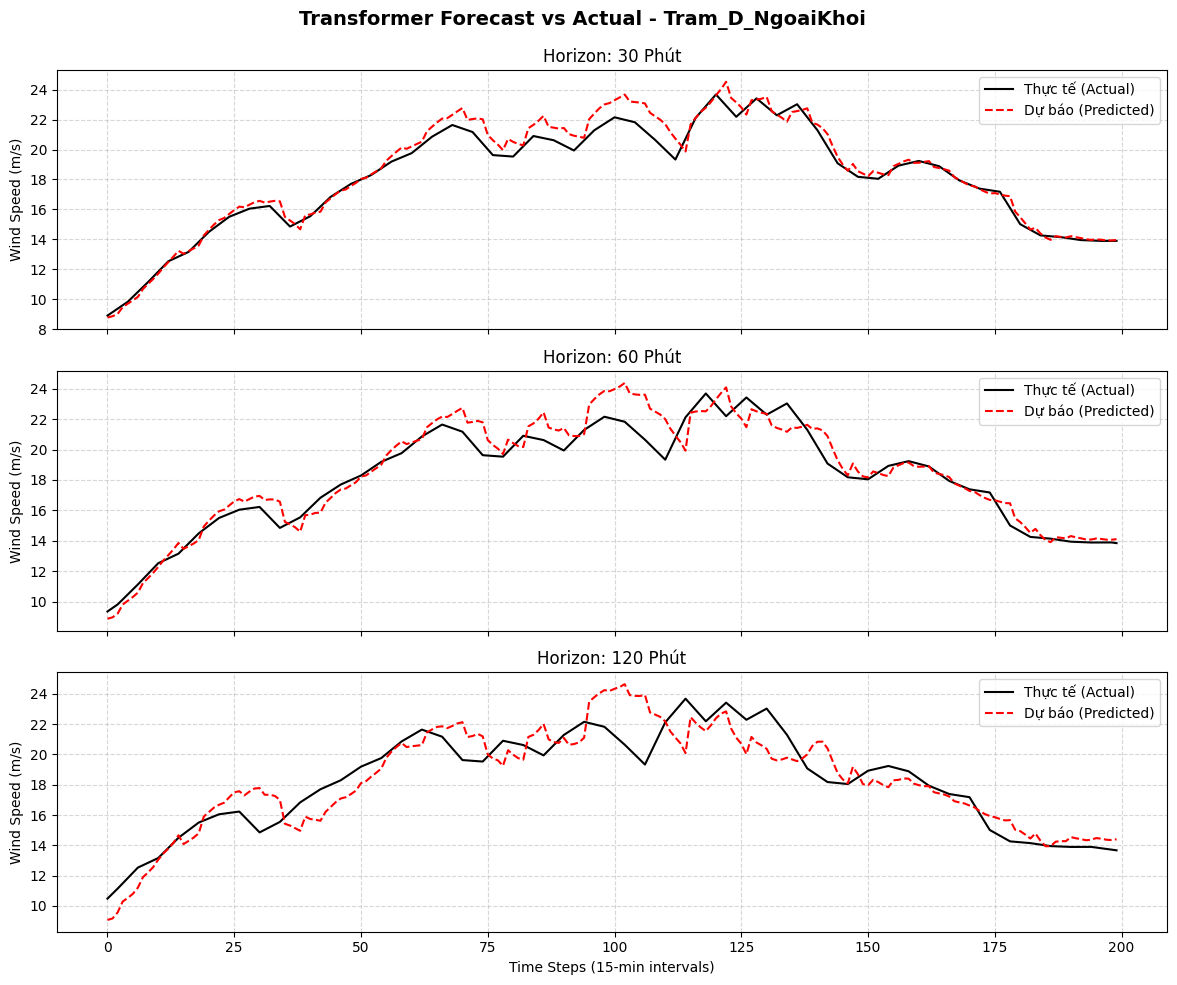

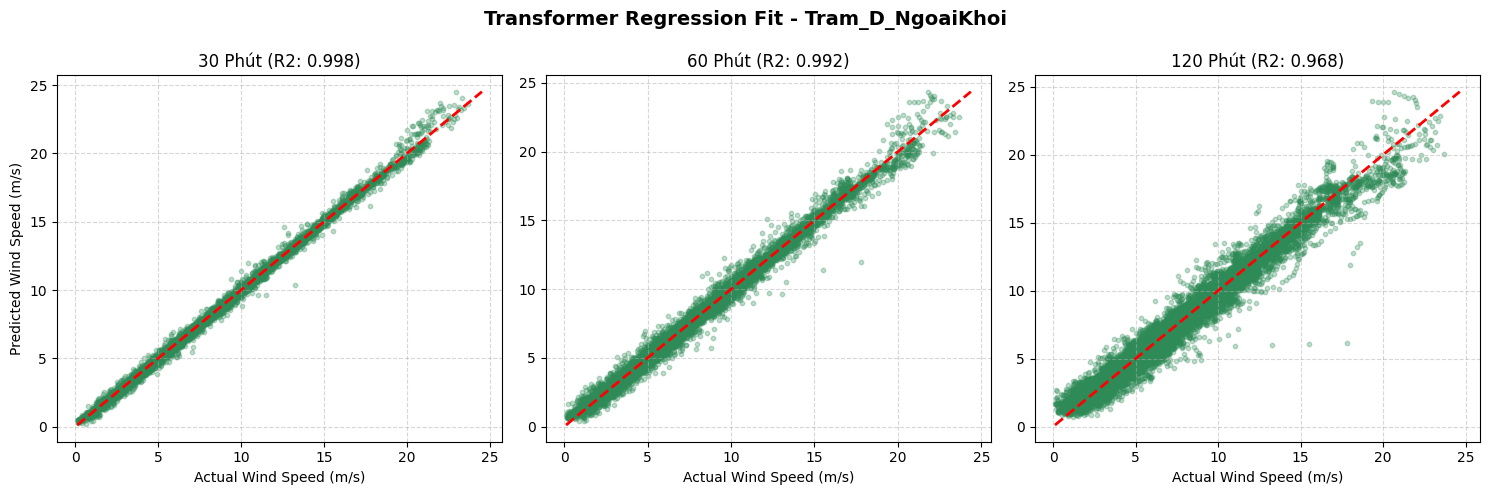


Hoàn thành pipeline!
Tổng thời gian chạy: 16.62 phút


In [8]:
stations = [
    "Tram_A_DatLien",
    "Tram_B_VenBien",
    "Tram_C_DoiNui",
    "Tram_D_NgoaiKhoi"
]

base_path = "/content/drive/MyDrive/WIND_FORECAST_DATA/"

print("TRANSFORMER...")

start_all = time.time()

for station in stations:
    file_path = f"{base_path}{station}_FINAL_MASTER.csv"

    print(f"\nĐang xử lý: {station}")

    try:
        train_transformer(file_path, station)
    except Exception as e:
        print(f"Lỗi tại {station}: {e}")

total_time = time.time() - start_all

print(f"\nHoàn thành pipeline!")
print(f"Tổng thời gian chạy: {total_time/60:.2f} phút")